<a href="https://colab.research.google.com/github/godwilltechorb/used-car-prediction-task/blob/main/used_car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used Car Price Prediction
## End-to-End Linear Regression Project

| | |
|---|---|
| **Dataset** | Car_data.csv — 301 rows, 9 columns |
| **Target** | `Selling_Price` (Lakhs ₹) |
| **Algorithm** | Linear Regression |
| **Evaluation** | MAE · RMSE · R² |

> **Scenario:** You are a junior data scientist at an online car marketplace.
> Build a model to estimate the selling price of used cars automatically.

---
## Step 1— Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2— Mount Google Drive & Load Dataset

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully!')

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
# Step 2: Load dataset from Drive
# ⚠️  Update this path to match your Drive folder structure. Double-check if 'Car_data.csv' is directly in 'My Drive' or in a subfolder.
file_path = '/content/drive/MyDrive/Car_data_jtrjuw.csv'

df = pd.read_csv(file_path)
print(f'✅ Dataset loaded from: {file_path}')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
df.head()

✅ Dataset loaded from: /content/drive/MyDrive/Car_data_jtrjuw.csv
Shape: 301 rows × 9 columns
Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


---
##  Problem Understanding

In [ ]:
print('='*60)
print('  BUSINESS PROBLEM')
print('='*60)
print("""
An online car marketplace needs to AUTOMATICALLY ESTIMATE
the selling price of used cars.

This helps:
  • Sellers price their listings competitively
  • Buyers recognise fair market value
  • The platform validate listings and flag overpricing
""")
print('='*60)
print('  TARGET VARIABLE & FEATURES')
print('='*60)
print("""
  Target  (y): Selling_Price — price the car sold for (Lakhs ₹)

  Features (X):
    Car_Name      — model/make of car
    Year          — year manufactured
    Present_Price — current showroom price
    Kms_Driven    — total kilometres driven
    Fuel_Type     — Petrol / Diesel / CNG
    Seller_Type   — Dealer / Individual
    Transmission  — Manual / Automatic
    Owner         — number of previous owners

  Task    : Supervised Regression
  Model   : Linear Regression
""")

  BUSINESS PROBLEM

An online car marketplace needs to AUTOMATICALLY ESTIMATE
the selling price of used cars.

This helps:
  • Sellers price their listings competitively
  • Buyers recognise fair market value
  • The platform validate listings and flag overpricing

  TARGET VARIABLE & FEATURES

  Target  (y): Selling_Price — price the car sold for (Lakhs ₹)

  Features (X):
    Car_Name      — model/make of car
    Year          — year manufactured
    Present_Price — current showroom price
    Kms_Driven    — total kilometres driven
    Fuel_Type     — Petrol / Diesel / CNG
    Seller_Type   — Dealer / Individual
    Transmission  — Manual / Automatic
    Owner         — number of previous owners

  Task    : Supervised Regression
  Model   : Linear Regression



---
## Data Exploration (EDA)

In [ ]:
# 2.1 — Shape, info, sample
print(f'Dataset shape: {df.shape}')
print()
df.info()

Dataset shape: (301, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
# 2.2 — Summary statistics (min, max, mean, std, quartiles)
# KEY: Selling_Price ranges 0.1 – 35 Lakhs; right-skewed
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing: 0


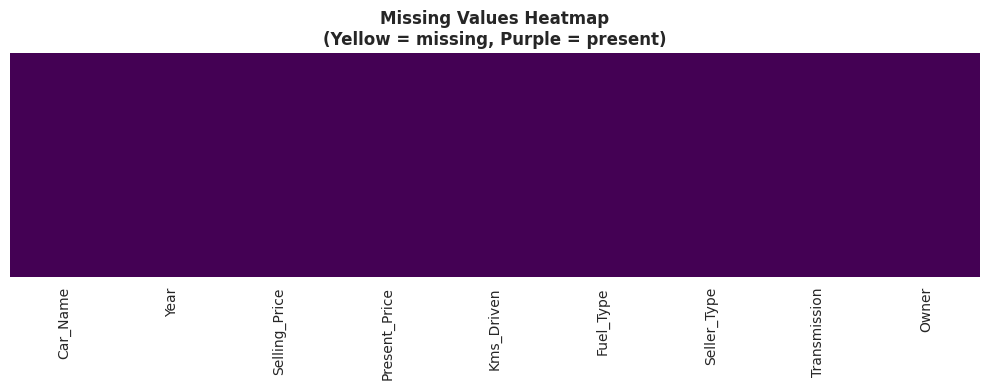

✅ No missing values — no imputation required


In [ ]:
# 2.3 — Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

# Visual heatmap of missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap\n(Yellow = missing, Purple = present)', fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ No missing values — no imputation required')

In [ ]:
# 2.4 — Duplicate check
dups = df.duplicated().sum()
print(f'Duplicate rows found: {dups}')
if dups > 0:
    print('(Will be removed in preprocessing step)')

Duplicate rows found: 2
(Will be removed in preprocessing step)


In [ ]:
# 2.5 — Categorical column distributions
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())
    print(f'  (% distribution: {(df[col].value_counts(normalize=True)*100).round(1).to_dict()})')


--- Fuel_Type ---
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
  (% distribution: {'Petrol': 79.4, 'Diesel': 19.9, 'CNG': 0.7})

--- Seller_Type ---
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
  (% distribution: {'Dealer': 64.8, 'Individual': 35.2})

--- Transmission ---
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64
  (% distribution: {'Manual': 86.7, 'Automatic': 13.3})

--- Owner ---
Owner
0    290
1     10
3      1
Name: count, dtype: int64
  (% distribution: {0: 96.3, 1: 3.3, 3: 0.3})


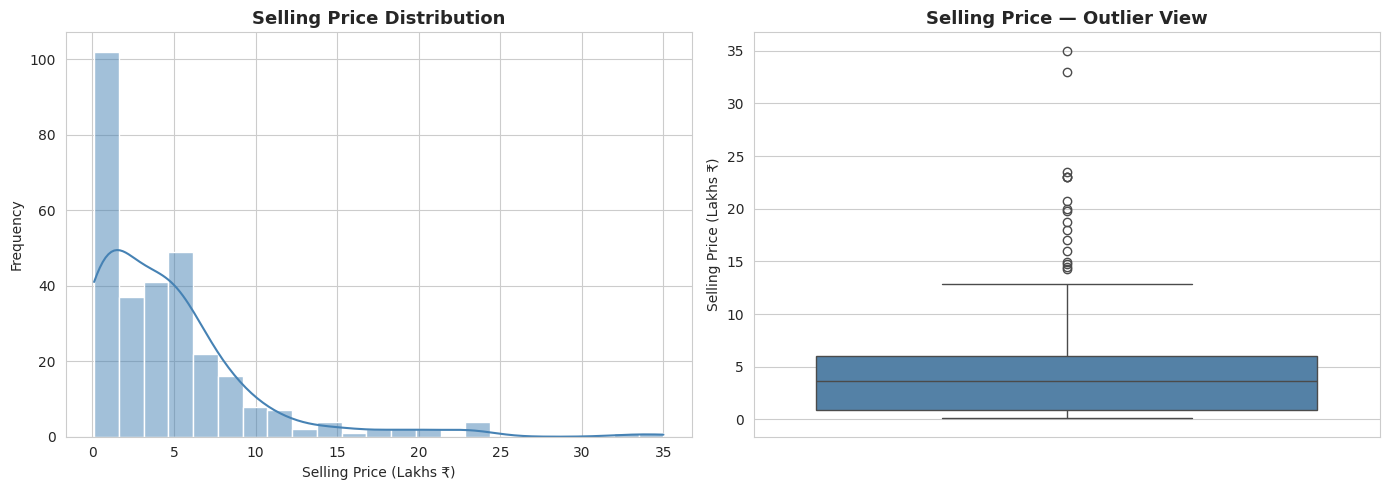

Price range : ₹0.1L  to  ₹35.0L
Mean price  : ₹4.66L
Median price: ₹3.60L

 Mean > Median → right-skewed (expensive cars pull the mean up)


In [ ]:
# 2.6 — Selling Price distribution
# Right-skewed: most cars sell for under ₹10L; a few luxury outliers at ₹35L
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Selling_Price'], kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Selling Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Selling Price (Lakhs ₹)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['Selling_Price'], color='steelblue', ax=axes[1])
axes[1].set_title('Selling Price — Outlier View', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Selling Price (Lakhs ₹)')
plt.tight_layout()
plt.show()

print(f'Price range : ₹{df["Selling_Price"].min()}L  to  ₹{df["Selling_Price"].max()}L')
print(f'Mean price  : ₹{df["Selling_Price"].mean():.2f}L')
print(f'Median price: ₹{df["Selling_Price"].median():.2f}L')
print('\n Mean > Median → right-skewed (expensive cars pull the mean up)')

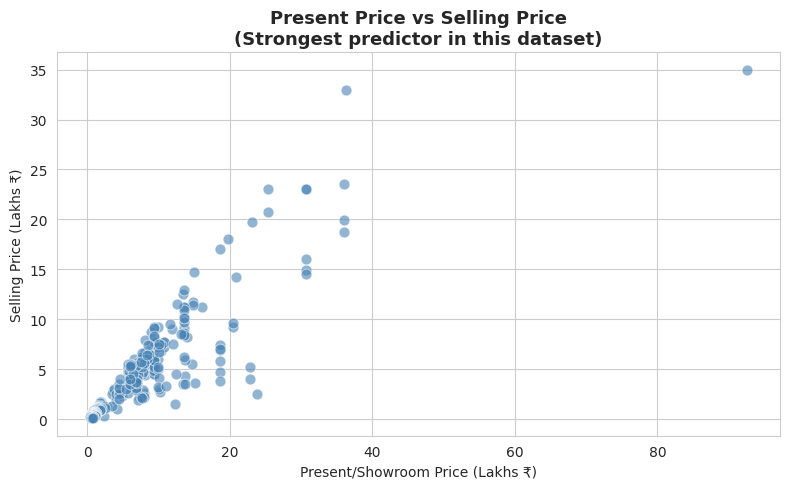

Clear positive relationship — higher showroom price → higher resale value


In [ ]:
# 2.7 — Present Price vs Selling Price (MOST IMPORTANT relationship)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df,
                color='steelblue', alpha=0.6, edgecolor='white', s=60)
plt.title('Present Price vs Selling Price\n(Strongest predictor in this dataset)',
          fontsize=13, fontweight='bold')
plt.xlabel('Present/Showroom Price (Lakhs ₹)')
plt.ylabel('Selling Price (Lakhs ₹)')
plt.tight_layout()
plt.show()
print('Clear positive relationship — higher showroom price → higher resale value')

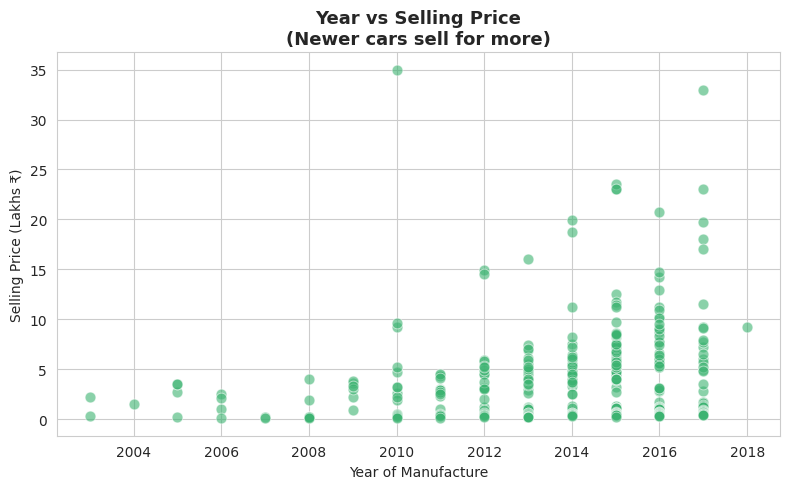

 Cars from 2014+ cluster at higher selling prices


In [ ]:
# 2.8 — Year vs Selling Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Year', y='Selling_Price', data=df,
                color='mediumseagreen', alpha=0.6, edgecolor='white', s=60)
plt.title('Year vs Selling Price\n(Newer cars sell for more)',
          fontsize=13, fontweight='bold')
plt.xlabel('Year of Manufacture')
plt.ylabel('Selling Price (Lakhs ₹)')
plt.tight_layout()
plt.show()
print(' Cars from 2014+ cluster at higher selling prices')

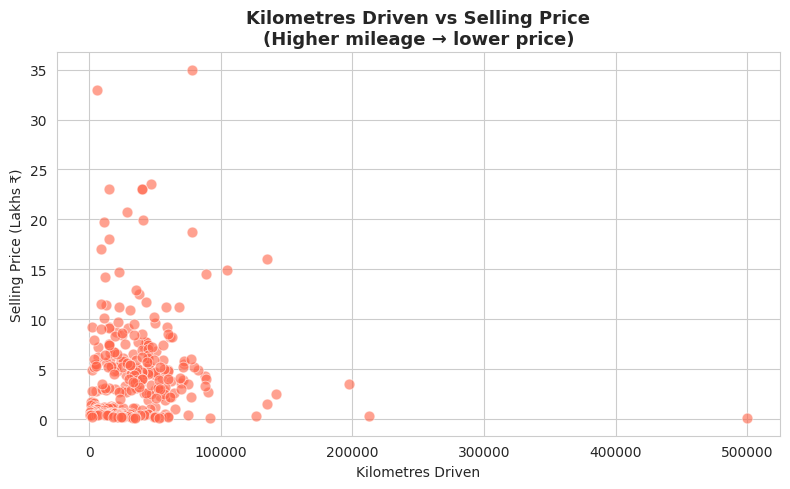

 Most high-priced cars have under 50,000 km


In [ ]:
# 2.9 — Kms Driven vs Selling Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df,
                color='tomato', alpha=0.6, edgecolor='white', s=60)
plt.title('Kilometres Driven vs Selling Price\n(Higher mileage → lower price)',
          fontsize=13, fontweight='bold')
plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price (Lakhs ₹)')
plt.tight_layout()
plt.show()
print(' Most high-priced cars have under 50,000 km')

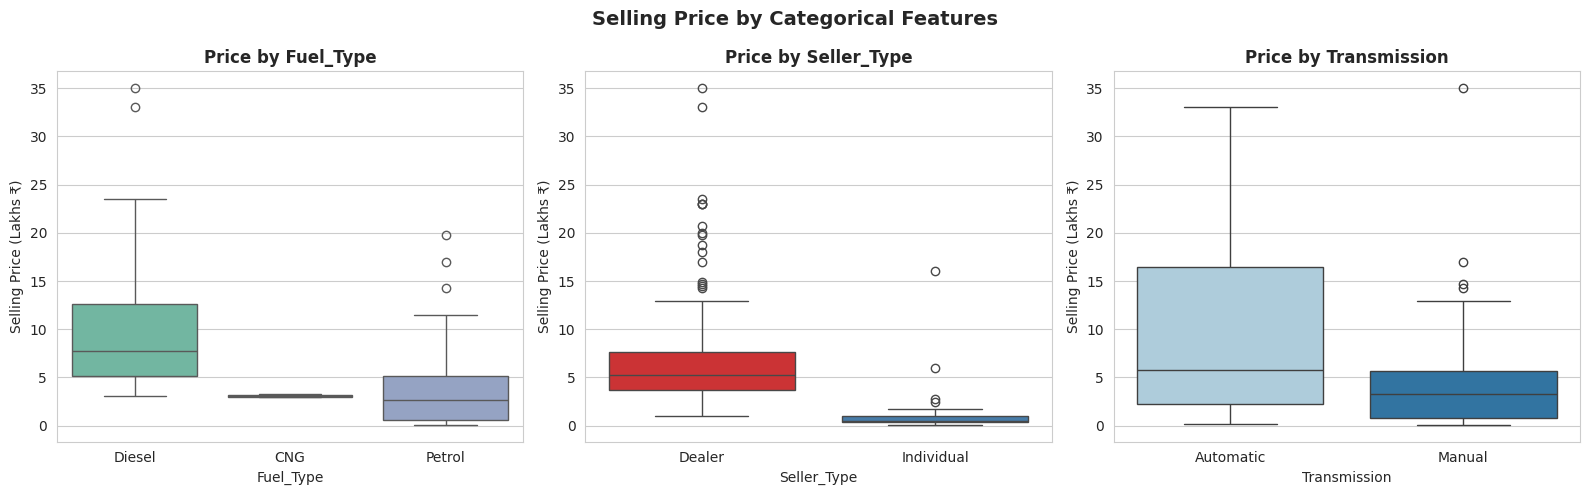

 Diesel > Petrol | Dealer > Individual | Automatic > Manual


In [ ]:
# 2.10 — Categorical features vs Price (Fuel Type, Seller Type, Transmission)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, pal in zip(axes,
                         ['Fuel_Type','Seller_Type','Transmission'],
                         ['Set2','Set1','Paired']):
    order = df.groupby(col)['Selling_Price'].median().sort_values(ascending=False).index
    sns.boxplot(x=col, y='Selling_Price', data=df, order=order, palette=pal, ax=ax)
    ax.set_title(f'Price by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Selling Price (Lakhs ₹)')
plt.suptitle('Selling Price by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(' Diesel > Petrol | Dealer > Individual | Automatic > Manual')

In [ ]:
# 2.11 — Outlier Detection via IQR
print('Outlier Detection (IQR method)\n')
print(f'{"Column":<20} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"# Outliers":>12}')
print('-'*60)
for col in ['Selling_Price', 'Present_Price', 'Kms_Driven']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 1.5*IQR
    high = Q3 + 1.5*IQR
    n = len(df[(df[col] < low) | (df[col] > high)])
    print(f'{col:<20} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {n:>12}')

print('\n Outliers exist (luxury cars, high-km vehicles).')
print('   We retain them — they represent real data, not errors.')

Outlier Detection (IQR method)

Column                     Q1       Q3      IQR   # Outliers
------------------------------------------------------------
Selling_Price            0.90     6.00     5.10           17
Present_Price            1.20     9.90     8.70           14
Kms_Driven           15000.00 48767.00 33767.00            8

 Outliers exist (luxury cars, high-km vehicles).
   We retain them — they represent real data, not errors.


---
## 3. Data Preprocessing

Full pipeline: duplicates → data types → text standardisation → missing values → feature engineering → encoding → scaling

In [ ]:
# Step 1 — Check dataset structure
print('Step 1: Dataset Structure')
df.info()

Step 1: Dataset Structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
# Step 2 — Remove duplicate rows
# The dataset contains 2 identical rows that should be removed.
print(f'Before: {df.shape[0]} rows')
df.drop_duplicates(inplace=True)
print(f'After : {df.shape[0]} rows')
print(f'Removed: {301 - df.shape[0]} duplicate rows ✅')

Before: 301 rows
After : 299 rows
Removed: 2 duplicate rows ✅


In [ ]:
# Step 3 — Verify and correct data types
# All types are already correct in this dataset, but we confirm.
print('Data type check:')
print(df.dtypes)
print('\n✅ All types are correct — no coercion needed')

# If types were wrong, we would fix like this:
# df['Selling_Price'] = pd.to_numeric(df['Selling_Price'], errors='coerce')
# df['Year']          = pd.to_numeric(df['Year'], errors='coerce')

Data type check:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

✅ All types are correct — no coercion needed


In [ ]:
# Step 4 — Standardise text (strip whitespace + title case)
# Prevents 'toyota' and 'Toyota' being treated as different values.
for col in ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']:
    df[col] = df[col].str.strip().str.title()

print('Text standardised (strip + title case) ✅')
print('\nFuel_Type values:', df['Fuel_Type'].unique())
print('Seller_Type values:', df['Seller_Type'].unique())
print('Transmission values:', df['Transmission'].unique())

Text standardised (strip + title case) ✅

Fuel_Type values: ['Petrol' 'Diesel' 'Cng']
Seller_Type values: ['Dealer' 'Individual']
Transmission values: ['Manual' 'Automatic']


In [ ]:
# Step 5 — Handle missing values (defensive code — dataset is clean)
# Numerical columns → median (robust to outliers)
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled {col} with median')

# Categorical columns → mode (most frequent)
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  Filled {col} with mode')

print(f'Total missing values remaining: {df.isnull().sum().sum()} ✅')

Total missing values remaining: 0 ✅


In [ ]:
# Step 6 — Feature Engineering: Car_Age
# Car_Age = 2024 − Year is more interpretable than raw Year.
# Expected: older car (higher Car_Age) → lower selling price.
df['Car_Age'] = 2024 - df['Year']
df.drop(columns=['Year'], inplace=True)     # Year no longer needed

print('Car_Age engineered from Year ✅')
print(df[['Car_Age','Selling_Price']].head(6))

Car_Age engineered from Year ✅
   Car_Age  Selling_Price
0       10           3.35
1       11           4.75
2        7           7.25
3       13           2.85
4       10           4.60
5        6           9.25


In [ ]:
# Step 7 — Encode categorical variables
# Linear Regression requires numbers — LabelEncoder converts text to integers.
le = LabelEncoder()
cat_cols = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'Encoded: {col}')

print('\n✅ All categorical columns encoded!')
df.head()

Encoded: Car_Name
Encoded: Fuel_Type
Encoded: Seller_Type
Encoded: Transmission

✅ All categorical columns encoded!


,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,73,3.35,5.59,27000,2,0,1,0,10
1,82,4.75,9.54,43000,1,0,1,0,11
2,24,7.25,9.85,6900,2,0,1,0,7
3,91,2.85,4.15,5200,2,0,1,0,13
4,81,4.60,6.87,42450,1,0,1,0,10


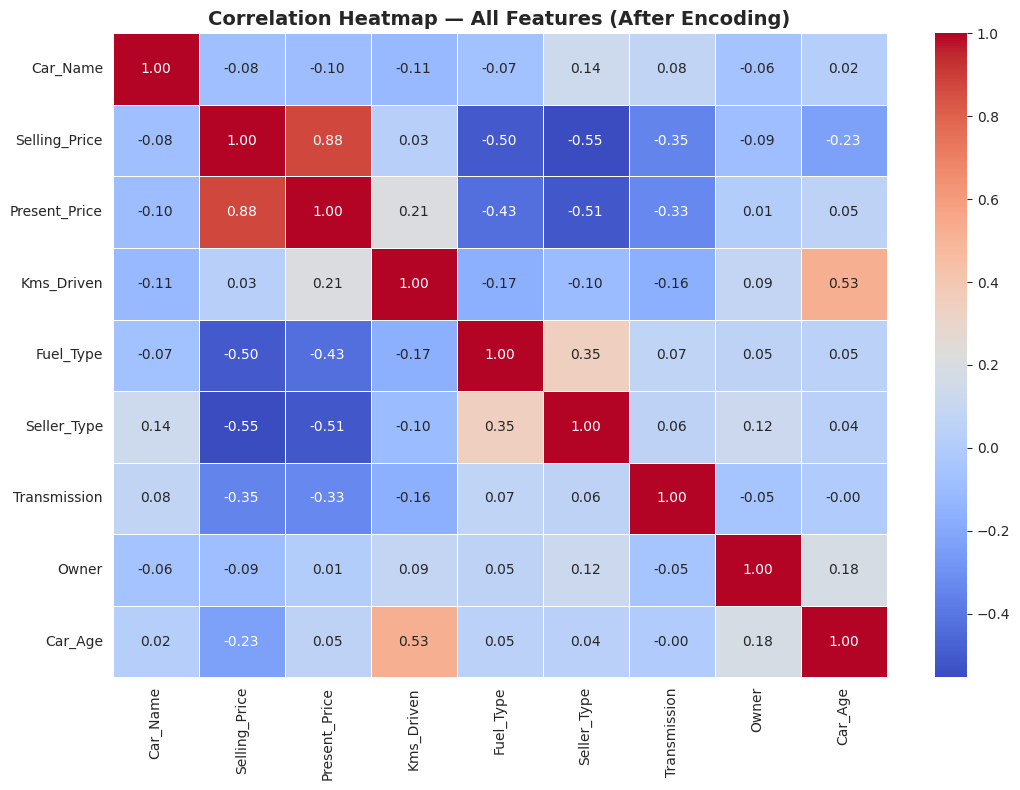


Top correlations with Selling_Price:
Present_Price    0.876378
Kms_Driven       0.028566
Car_Name        -0.084582
Owner           -0.087880
Car_Age         -0.234369
Transmission    -0.348869
Fuel_Type       -0.500292
Seller_Type     -0.553851


In [ ]:
# Step 8 — Correlation heatmap AFTER encoding
# Now we can see how EVERY feature relates to Selling_Price.
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Heatmap — All Features (After Encoding)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nTop correlations with Selling_Price:')
print(df.corr()['Selling_Price'].drop('Selling_Price').sort_values(ascending=False).to_string())

In [ ]:
# Step 9 — Final verification
print('Final dataset info after all preprocessing:')
print(f'  Shape            : {df.shape}')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print(f'  Dtypes           : all numeric — {df.dtypes.unique()}')
df.describe()

Final dataset info after all preprocessing:
  Shape            : (299, 9)
  Missing values   : 0
  Dtypes           : all numeric — [dtype('int64') dtype('float64')]


,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,46.622074,4.589632,7.541037,36916.752508,1.792642,0.354515,0.869565,0.043478,10.384615
std,27.140345,4.984240,8.567887,39015.170352,0.422297,0.479168,0.337346,0.248720,2.896868
min,0.000000,0.100000,0.320000,500.000000,0.000000,0.000000,0.000000,0.000000,6.000000
25%,25.000000,0.850000,1.200000,15000.000000,2.000000,0.000000,1.000000,0.000000,8.000000
50%,38.000000,3.510000,6.100000,32000.000000,2.000000,0.000000,1.000000,0.000000,10.000000
75%,70.500000,6.000000,9.840000,48883.500000,2.000000,1.000000,1.000000,0.000000,12.000000
max,97.000000,35.000000,92.600000,500000.000000,2.000000,1.000000,1.000000,3.000000,21.000000


---
## 4. Model Building — Linear Regression

In [ ]:
# Define Features and Target
X = df.drop(columns=['Selling_Price'])   # All columns except target
y = df['Selling_Price']                  # Target

print(f'Features (X): {X.columns.tolist()}')
print(f'Target   (y): Selling_Price')
print(f'X shape: {X.shape}  |  y shape: {y.shape}')

Features (X): ['Car_Name', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
Target   (y): Selling_Price
X shape: (299, 8)  |  y shape: (299,)


In [ ]:
# Train / Test Split — 80% train, 20% test
# random_state=42 ensures the same split every run (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training samples : {X_train.shape[0]}  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing  samples : {X_test.shape[0]}  ({X_test.shape[0]/len(X)*100:.0f}%)')

Training samples : 239  (80%)
Testing  samples : 60  (20%)


In [ ]:
# Feature Scaling (StandardScaler)
# Without scaling, Kms_Driven (0–500,000) would dominate Owner (0–3).
# Rule: fit ONLY on training data, transform both — prevents data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only!

print('✅ StandardScaler applied (mean=0, std=1 for each feature)')
print(f'   Training set mean ≈ {X_train_scaled.mean():.4f}')

✅ StandardScaler applied (mean=0, std=1 for each feature)
   Training set mean ≈ -0.0000


In [ ]:
# Train Linear Regression
# The model learns: Selling_Price = β₀ + β₁×Feature1 + β₂×Feature2 + ...
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('✅ Linear Regression model trained!')
print(f'\nIntercept (β₀): {model.intercept_:.4f}')
print('\nFeature Coefficients:')
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)

for _, row in coef_df.iterrows():
    direction = '▲ raises price' if row['Coefficient'] > 0 else '▼ lowers price'
    print(f"  {row['Feature']:<20} {row['Coefficient']:>8.4f}  →  {direction}")

✅ Linear Regression model trained!

Intercept (β₀): 4.5837

Feature Coefficients:
  Present_Price          3.8918  →  ▲ raises price
  Car_Age               -0.9916  →  ▼ lowers price
  Seller_Type           -0.6219  →  ▼ lowers price
  Transmission          -0.5313  →  ▼ lowers price
  Fuel_Type             -0.4906  →  ▼ lowers price
  Kms_Driven            -0.2579  →  ▼ lowers price
  Owner                  0.1233  →  ▲ raises price
  Car_Name               0.0393  →  ▲ raises price


---
## 5. Model Evaluation

In [ ]:
# Generate predictions on the TEST set (data the model has never seen)
y_pred = model.predict(X_test_scaled)

# Show actual vs predicted side by side
comparison = pd.DataFrame({
    'Actual Price (₹L)': y_test.values,
    'Predicted Price (₹L)': y_pred.round(2)
})
print('Actual vs Predicted (first 10 test samples):')
print(comparison.head(10).to_string(index=False))

Actual vs Predicted (first 10 test samples):
 Actual Price (₹L)  Predicted Price (₹L)
              8.99                  7.52
              8.35                  7.57
              0.45                  1.35
              7.45                  6.80
              5.25                 11.25
              5.25                  4.51
              5.85                  8.57
              1.15                  1.75
              9.25                  8.70
              0.38                 -0.95


In [ ]:
# Compute evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('='*58)
print('         MODEL EVALUATION RESULTS')
print('='*58)
print(f'  MAE  (Mean Absolute Error)       : ₹{mae:.4f} Lakhs')
print(f'  RMSE (Root Mean Squared Error)   : ₹{rmse:.4f} Lakhs')
print(f'  R²   (Coefficient of Det.)       : {r2:.4f}  ({r2*100:.2f}%)')
print('='*58)
print()
print(' What these metrics mean:')
print(f'   MAE  → On average, predictions are off by ₹{mae:.2f}L')
print(f'   RMSE → Penalises big errors; ₹{rmse:.2f}L includes some large misses')
print(f'   R²   → Model explains {r2*100:.1f}% of price variation in test data')
print()
# R² interpretation
if r2 >= 0.90:   grade = 'Excellent'
elif r2 >= 0.80: grade = 'Very Good'
elif r2 >= 0.70: grade = 'Good'
elif r2 >= 0.50: grade = 'Fair'
else:            grade = 'Poor'
print(f'   R² Grade: {grade} (0.70–0.79 = Good | 0.80–0.89 = Very Good | 0.90+ = Excellent)')

         MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error)       : ₹1.5529 Lakhs
  RMSE (Root Mean Squared Error)   : ₹2.5897 Lakhs
  R²   (Coefficient of Det.)       : 0.7398  (73.98%)

 What these metrics mean:
   MAE  → On average, predictions are off by ₹1.55L
   RMSE → Penalises big errors; ₹2.59L includes some large misses
   R²   → Model explains 74.0% of price variation in test data

   R² Grade: Good (0.70–0.79 = Good | 0.80–0.89 = Very Good | 0.90+ = Excellent)


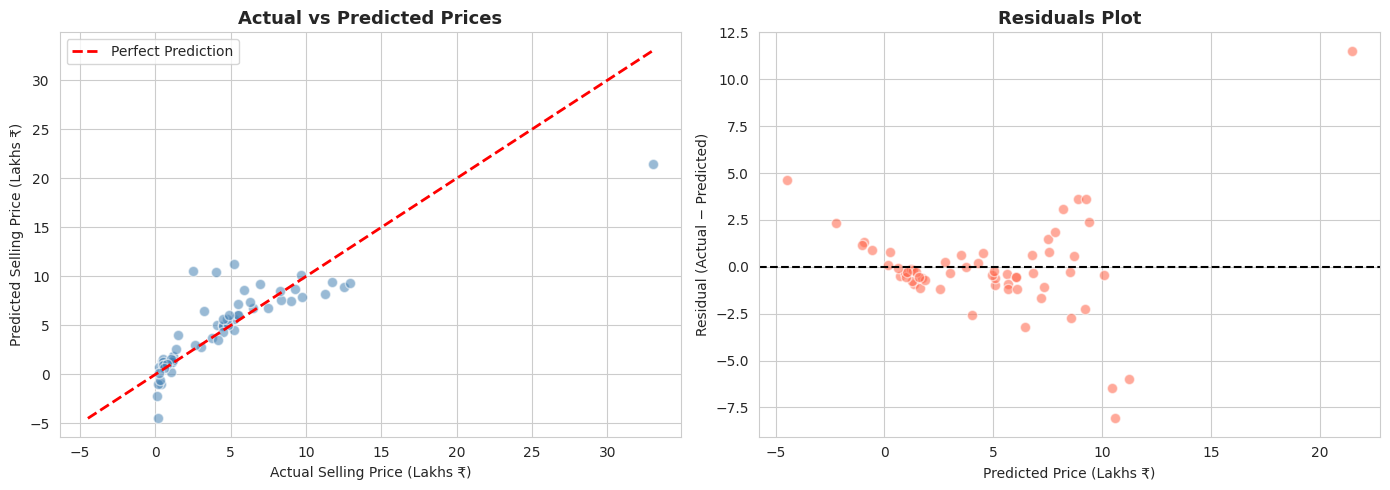

 Good model: residuals scattered randomly around 0 (no obvious pattern)


In [ ]:
# Actual vs Predicted scatter + Residuals plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.55, color='steelblue', edgecolors='white', s=55)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Selling Price (Lakhs ₹)')
axes[0].set_ylabel('Predicted Selling Price (Lakhs ₹)')
axes[0].set_title('Actual vs Predicted Prices', fontsize=13, fontweight='bold')
axes[0].legend()

residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.55, color='tomato', edgecolors='white', s=55)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Price (Lakhs ₹)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residuals Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(' Good model: residuals scattered randomly around 0 (no obvious pattern)')

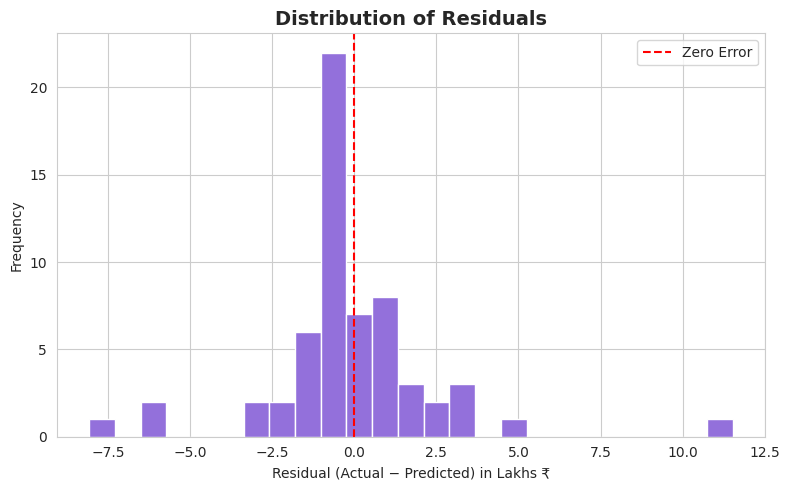

Mean residual: -0.1374  (ideal = 0.0000)


In [ ]:
# Residuals distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25, color='mediumpurple', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero Error')
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.xlabel('Residual (Actual − Predicted) in Lakhs ₹')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Mean residual: {residuals.mean():.4f}  (ideal = 0.0000)')

---
## 6. Prediction — 5 Sample Cars

In [ ]:
# Predict price for the first 5 test cars
sample_cars       = X_test.iloc[:5]
sample_scaled     = X_test_scaled[:5]
sample_actual     = y_test.iloc[:5].values
sample_predicted  = model.predict(sample_scaled)

print('='*68)
print('      PRICE PREDICTIONS FOR 5 SAMPLE CARS')
print('='*68)
print(f'{"Car #":<7} {"Actual":>12} {"Predicted":>12} {"Error":>10} {"Accuracy":>10}')
print('-'*68)
for i, (a, p) in enumerate(zip(sample_actual, sample_predicted), 1):
    err = a - p
    acc = max(0, 100 - abs(err/a)*100) if a > 0 else 0
    print(f'Car {i:<3} {"₹"+f"{a:.2f}L":>12} {"₹"+f"{p:.2f}L":>12} {"₹"+f"{err:.2f}L":>10} {acc:>9.1f}%')
print('='*68)

# DataFrame version (clean output)
results = pd.DataFrame({
    'Actual Price (₹L)': sample_actual.round(2),
    'Predicted Price (₹L)': sample_predicted.round(2),
    'Difference (₹L)': (sample_actual - sample_predicted).round(2)
})
results.index = [f'Car {i}' for i in range(1,6)]
results

      PRICE PREDICTIONS FOR 5 SAMPLE CARS
Car #         Actual    Predicted      Error   Accuracy
--------------------------------------------------------------------
Car 1         ₹8.99L       ₹7.52L     ₹1.47L      83.6%
Car 2         ₹8.35L       ₹7.57L     ₹0.78L      90.6%
Car 3         ₹0.45L       ₹1.35L    ₹-0.90L       0.0%
Car 4         ₹7.45L       ₹6.80L     ₹0.65L      91.3%
Car 5         ₹5.25L      ₹11.25L    ₹-6.00L       0.0%


,Actual Price (₹L),Predicted Price (₹L),Difference (₹L)
Car 1,8.99,7.52,1.47
Car 2,8.35,7.57,0.78
Car 3,0.45,1.35,-0.90
Car 4,7.45,6.80,0.65
Car 5,5.25,11.25,-6.00


---
## 7. Insights

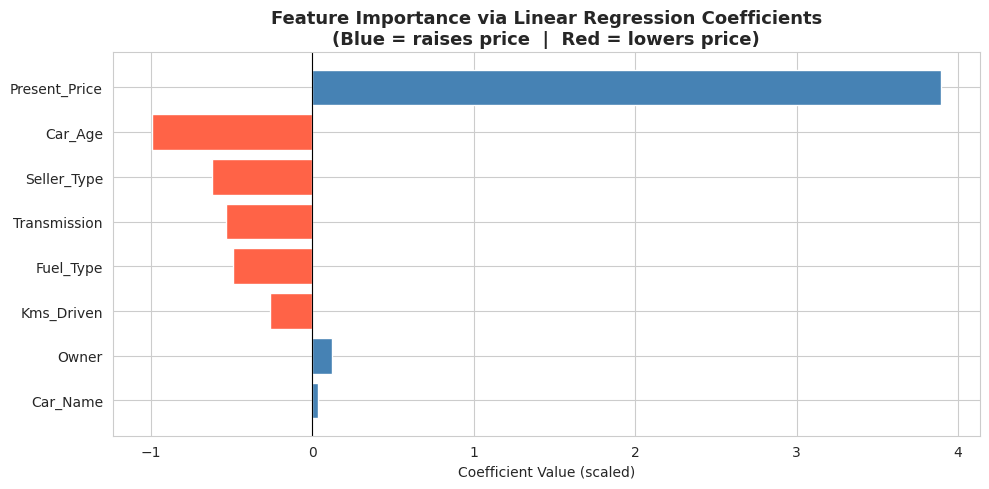

In [ ]:
# Feature Importance via Coefficients
coef_plot = coef_df.sort_values('Coefficient', key=abs)
bar_colors = ['steelblue' if c > 0 else 'tomato' for c in coef_plot['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(coef_plot['Feature'], coef_plot['Coefficient'],
         color=bar_colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Feature Importance via Linear Regression Coefficients\n'
          '(Blue = raises price  |  Red = lowers price)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value (scaled)')
plt.tight_layout()
plt.show()

In [ ]:
# Written Insights
print('='*65)
print('  INSIGHT 1: What factors most influence car price?')
print('='*65)
print("""
Based on the linear regression coefficients and correlation analysis:

1. PRESENT_PRICE (showroom price) — DOMINANT positive driver
   Coefficient: ~3.89 (largest of all features)
   Cars with high original prices retain high resale value.
   This reflects brand tier, engine quality, and features.

2. CAR_AGE — significant NEGATIVE driver
   Coefficient: −0.99
   Each additional year of age reduces selling price.
   Depreciation is steepest in years 1–5.

3. SELLER_TYPE — Dealers fetch higher prices
   Coefficient: −0.62 (Individual coded higher → lower price)
   Dealer-sold cars are priced higher: serviced, warrantied, trusted.

4. TRANSMISSION — Automatic commands a premium
   Coefficient: −0.53
   Buyers pay more for Automatic convenience.

5. FUEL_TYPE — Diesel > Petrol
   Coefficient: −0.49
   Diesel cars retain value due to fuel efficiency on long drives.
""")
print('='*65)
print('  INSIGHT 2: What surprised us in the data?')
print('='*65)
print("""
• PRESENT_PRICE explained the largest share of price variation.
  A single feature carried most of the predictive power.

• KMS_DRIVEN had a WEAKER effect than expected.
  Some high-mileage cars still sold well — brand/model matters more.

• OWNER count barely moved the price.
  Buyers may not deeply penalise 1 vs 3 previous owners.

• CNG cars (only 2 entries) cannot be analysed reliably.
  Too few samples for meaningful insight.

• The model underestimates prices above ₹20L (luxury segment).
  Premium car pricing is non-linear — a limitation of Linear Regression.
  A Random Forest or Gradient Boosting model would handle this better.
""")

  INSIGHT 1: What factors most influence car price?

Based on the linear regression coefficients and correlation analysis:

1. PRESENT_PRICE (showroom price) — DOMINANT positive driver
   Coefficient: ~3.89 (largest of all features)
   Cars with high original prices retain high resale value.
   This reflects brand tier, engine quality, and features.

2. CAR_AGE — significant NEGATIVE driver
   Coefficient: −0.99
   Each additional year of age reduces selling price.
   Depreciation is steepest in years 1–5.

3. SELLER_TYPE — Dealers fetch higher prices
   Coefficient: −0.62 (Individual coded higher → lower price)
   Dealer-sold cars are priced higher: serviced, warrantied, trusted.

4. TRANSMISSION — Automatic commands a premium
   Coefficient: −0.53
   Buyers pay more for Automatic convenience.

5. FUEL_TYPE — Diesel > Petrol
   Coefficient: −0.49
   Diesel cars retain value due to fuel efficiency on long drives.

  INSIGHT 2: What surprised us in the data?

• PRESENT_PRICE explained t

In [ ]:
# Final Summary
print('='*55)
print('         FINAL PROJECT SUMMARY')
print('='*55)
print(f'  Dataset      : 301 cars (299 after dedup)')
print(f'  Algorithm    : Linear Regression')
print(f'  Features used: {len(X.columns)}')
print(f'  Train / Test : 80% / 20%')
print(f'  MAE          : ₹{mae:.4f} Lakhs')
print(f'  RMSE         : ₹{rmse:.4f} Lakhs')
print(f'  R² Score     : {r2:.4f}  ({r2*100:.2f}% variance explained)')
print('='*55)
print('\n✅ Project complete — ready for GitHub submission!')

         FINAL PROJECT SUMMARY
  Dataset      : 301 cars (299 after dedup)
  Algorithm    : Linear Regression
  Features used: 8
  Train / Test : 80% / 20%
  MAE          : ₹1.5529 Lakhs
  RMSE         : ₹2.5897 Lakhs
  R² Score     : 0.7398  (73.98% variance explained)

✅ Project complete — ready for GitHub submission!


---
## 💾 Save Cleaned Dataset

In [ ]:
df.to_csv('car_price_cleaned.csv', index=False)
print('✅ Cleaned dataset saved as car_price_cleaned.csv')
print(f'   Rows: {df.shape[0]} | Columns: {df.shape[1]}')

✅ Cleaned dataset saved as car_price_cleaned.csv
   Rows: 299 | Columns: 9
